In [24]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [25]:
data_dir = "data/No_Apply_Grayscale/Vehicles_Detection.v8i.yolov8"
os.listdir(data_dir)

['data.yaml', 'test', 'train', 'valid']

In [26]:
train_dir = os.path.join(data_dir, "train")

In [27]:
def load_data(dir):
    img_dir = os.path.join(dir, "images")
    label_dir = os.path.join(dir, "labels")
    imgs = [cv2.imread(os.path.join(img_dir, img)) for img in os.listdir(img_dir)]
    labels = [[] for _ in range(len(imgs))]
    bbox = [[] for _ in range(len(imgs))]
    for i, label in enumerate(os.listdir(label_dir)):
        with open(os.path.join(label_dir, label)) as f:
            for line in f:
                class_id, x_max, y_max, x_min, y_min = map(float, line.split())
                labels[i].append(int(class_id))
                bbox[i].append((x_max, y_max, x_min, y_min))


    return imgs, labels, bbox

In [28]:
train_img, train_label, train_bbox = load_data(train_dir)

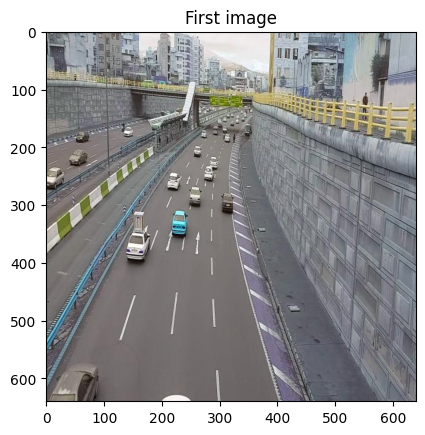

Labels:  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Object count:  27
B.box coordinate example:  (0.490625, 0.46484375, 0.03515625, 0.06484375)
Image shape:  (640, 640, 3)


In [29]:
plt.imshow(train_img[0])
plt.title("First image")
plt.show()
print("Labels: ", train_label[0])
print("Object count: ", len(train_label[0]))
print("B.box coordinate example: ", train_bbox[0][0])
print("Image shape: ", train_img[0].shape)

In [30]:
def convert_bbox(bbox, img_h, img_w): 
    x, y, w, h = bbox 
    x_min = int(img_w * (x - w / 2)) 
    y_min = int(img_h * (y - h / 2)) 
    x_max = int(img_w * (x + w / 2)) 
    y_max = int(img_h * (y + h / 2)) 
    return x_min, y_min, x_max, y_max


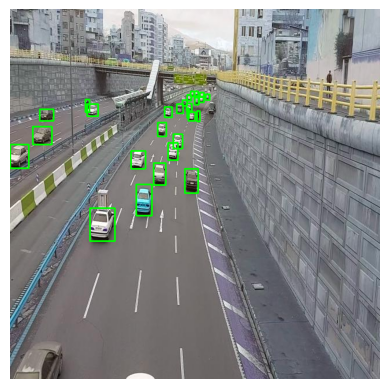

In [31]:
img_with_box = train_img[0].copy()
img_h, img_w, c = img_with_box.shape

for i in range(len(train_bbox[0])):
    x_min, y_min, x_max, y_max = convert_bbox(train_bbox[0][i], img_h, img_w)
    cv2.rectangle(img_with_box, (x_min, y_min), (x_max, y_max), (0, 255, 0), 2)

plt.imshow(img_with_box)
plt.axis('off')
plt.show()

In [35]:
invalid = 0
cnt_box = 0
border = 0
sum_area = 0
areas = []
ratios = []
for i, boxes in enumerate(train_bbox):
    img = train_img[i].copy()
    img_h, img_w, c = img_with_box.shape
    for box in boxes:
        x_min, y_min, x_max, y_max = convert_bbox(box, img_h, img_w)
        if(min(x_min, y_min) < 0 or x_max > img_w or y_max > img_h):
            invalid += 1
        if(img_w - x_max < 0.01 * img_w
           or img_h - y_max < 0.01 * img_h
           or x_min < 0.01 * img_w
           or y_min < 0.01 * img_h):
            border += 1
        cnt_box += 1
        area = (x_max - x_min) * (y_max - y_min)
        areas.append(area)
        ratios.append(area / (img_h * img_w))

areas = np.array(areas)
ratios = np.array(ratios)

In [ ]:
tiny = np.sum(ratios < 5e-4)


In [41]:
print("Sum of boxes: ", cnt_box)
print("Invalid boxes: ", invalid)
print("Border boxes:", border)
print("Tiny boxes: ", tiny)
print("Tiny boxes percentage", (tiny / cnt_box))

Sum of boxes:  2069
Invalid boxes:  0
Border boxes: 64
Tiny boxes:  94
Tiny boxes percentage 0.04543257612373127



Area statistic:
Min: 1
Max: 36162
Mean: 1210.1614306428226
Median: 312.0
Std: 2816.1685754198547


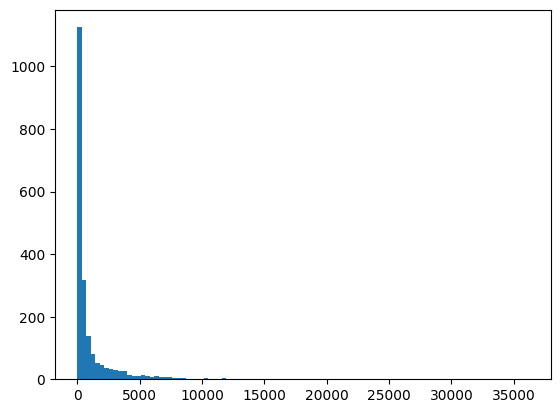

In [ ]:
print("\nArea statistic:")
print("Min:", np.min(areas))
print("Max:", np.max(areas))
print("Mean:", np.mean(areas))
print("Median:", np.median(areas))
print("Std:", np.std(areas))
plt.hist(np.array(areas).astype(int), bins=100)
plt.show()


Area ratio statistic:
Min: 2.44140625e-06
Max: 0.0882861328125
Mean: 0.0029544956802803287
Median: 0.00076171875
Std: 0.00687541156108363


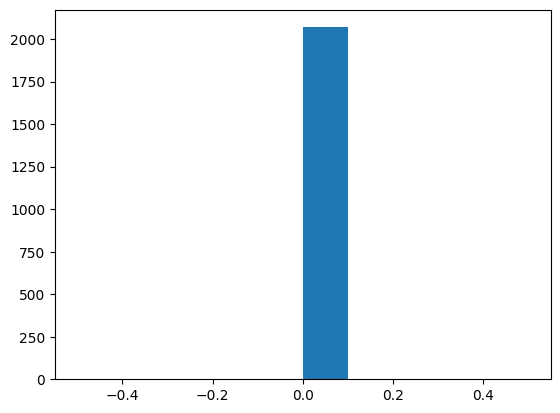

In [ ]:
print("\nArea ratio statistic:")
print("Min:", np.min(ratios))
print("Max:", np.max(ratios))
print("Mean:", np.mean(ratios))
print("Median:", np.median(ratios))
print("Std:", np.std(ratios))
plt.hist(np.array(ratios).astype(int), bins=10)
plt.show()